# Backtesting Framework Adapters

This notebook summarizes how De-Time signals can be routed into existing Python backtesting and reporting frameworks. The transparent pandas backtester should be used first to verify alignment and costs.

**Default decomposition:** `ROBUST_STL` with a 63-trading-day period, computed walk-forward where signals are backtested.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from examples.quant_trading.data import fetch_yahoo_prices, fetch_yahoo_ohlcv, data_audit_report, DEFAULT_UNIVERSES
from examples.quant_trading.features import decompose_one_series, walkforward_decompose, build_feature_table
from examples.quant_trading.signals import (
    trend_pullback_signals,
    residual_mean_reversion_signals,
    turtle_donchian_signals,
    pair_trading_weights,
    cross_sectional_rotation_weights,
    residual_stress_filter,
)
from examples.quant_trading.backtest import backtest_weights, backtest_long_short_signals, summarize_returns

DATA_CACHE = Path("examples/quant_trading/data/cache")
QUANT_METHOD = "ROBUST_STL"
QUANT_PERIOD = 63


In [2]:
prices = fetch_yahoo_prices(["SPY", "QQQ"], start="2018-01-01", cache_dir=DATA_CACHE)
features = walkforward_decompose(prices, method=QUANT_METHOD, period=QUANT_PERIOD, train_window=252, step=21)
entries, exits = turtle_donchian_signals(prices, features)
pandas_result = backtest_long_short_signals(prices, entries, exits)
pandas_result.stats_frame()

,value
total_return,0.750564
cagr,0.069195
volatility,0.094201
sharpe,0.757550
max_drawdown,-0.146767
calmar,0.471459
hit_rate,0.253201
average_turnover,0.029872
average_gross_exposure,0.449976
fee_bps,5.000000


## Adapter payload map

Framework adapters should receive already-audited signals or weights. They should not rerun decomposition internally, because that would hide timestamp alignment and make the backtest harder to audit.

In [3]:
pd.DataFrame([
    {"artifact": "walk-forward features", "contains": "trend_slope and other De-Time components", "adapter_role": "research input only, audited before handoff"},
    {"artifact": "entries / exits", "contains": "boolean signal matrices created from price plus De-Time trend filter", "adapter_role": "vectorbt/backtesting.py compatible signal payload"},
    {"artifact": "pandas_result.weights", "contains": "shifted target exposure produced by the transparent backtester", "adapter_role": "reference output for comparing external framework behavior"},
    {"artifact": "returns / costs / turnover", "contains": "after-cost accounting", "adapter_role": "must match or explain differences after adapter migration"},
])

,artifact,contains,adapter_role
0,walk-forward features,trend_slope and other De-Time components,"research input only, audited before handoff"
1,entries / exits,boolean signal matrices created from price plu...,vectorbt/backtesting.py compatible signal payload
2,pandas_result.weights,shifted target exposure produced by the transp...,reference output for comparing external framew...
3,returns / costs / turnover,after-cost accounting,must match or explain differences after adapte...


## Visualization: signal ingredients before framework handoff

Before routing the strategy to vectorbt, bt, or backtesting.py, inspect the decomposed trend filter and the target exposure created by the pandas reference path.

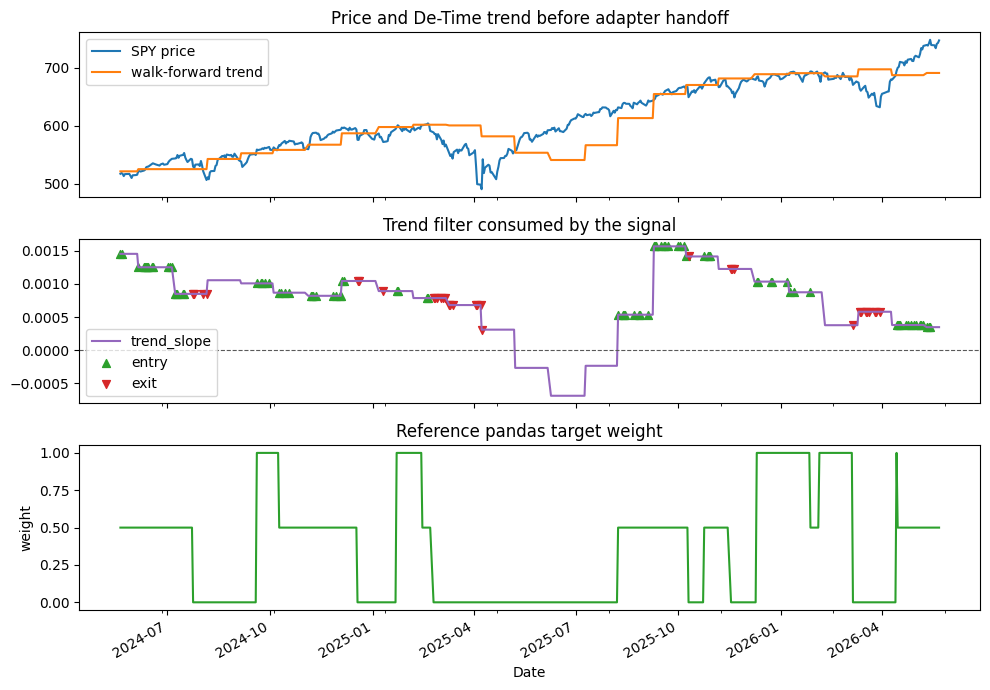

In [4]:
asset = "SPY"
window = prices.index[-504:]
trend_level = np.exp(features["trend"][asset]).reindex(window)
trend_slope = features["trend_slope"][asset].reindex(window)
position = pandas_result.weights[asset].reindex(window)
entry_points = entries.loc[window, asset].fillna(False).astype(bool)
exit_points = exits.loc[window, asset].fillna(False).astype(bool)

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
prices[asset].reindex(window).plot(ax=axes[0], color="tab:blue", label=f"{asset} price")
trend_level.plot(ax=axes[0], color="tab:orange", label="walk-forward trend")
axes[0].set_title("Price and De-Time trend before adapter handoff")
axes[0].legend(loc="best")
trend_slope.plot(ax=axes[1], color="tab:purple", label="trend_slope")
axes[1].axhline(0.0, color="0.35", linestyle="--", linewidth=0.8)
axes[1].scatter(entry_points[entry_points].index, trend_slope.loc[entry_points[entry_points].index], marker="^", color="tab:green", s=32, label="entry")
axes[1].scatter(exit_points[exit_points].index, trend_slope.loc[exit_points[exit_points].index], marker="v", color="tab:red", s=32, label="exit")
axes[1].set_title("Trend filter consumed by the signal")
axes[1].legend(loc="best")
position.plot(ax=axes[2], color="tab:green", title="Reference pandas target weight")
axes[2].set_ylabel("weight")
plt.tight_layout()
plt.show()

## Visualization: pandas baseline diagnostics

The pandas baseline now shows both risk and signal density before optional framework adapters are introduced.

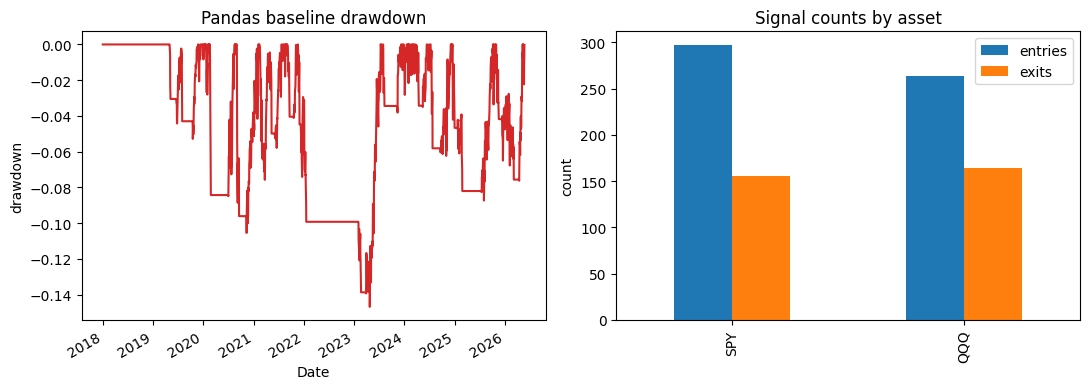

In [5]:
drawdown = pandas_result.equity / pandas_result.equity.cummax() - 1.0
signal_counts = pd.DataFrame({"entries": entries.sum(), "exits": exits.sum()})
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
drawdown.plot(ax=axes[0], color="tab:red", title="Pandas baseline drawdown")
signal_counts.plot(kind="bar", ax=axes[1], title="Signal counts by asset")
axes[0].set_ylabel("drawdown")
axes[1].set_ylabel("count")
plt.tight_layout()
plt.show()


In [6]:
from examples.quant_trading.frameworks import (
    run_vectorbt_from_signals,
    run_bt_target_weights,
    run_backtestingpy_signal,
    write_framework_templates,
    quantstats_html_report,
)

template_paths = write_framework_templates(Path("examples/quant_trading/templates"))
pd.DataFrame({"template": [path.as_posix() for path in template_paths]})

,template
0,examples/quant_trading/templates/backtrader_de...
1,examples/quant_trading/templates/zipline_reloa...


In [7]:
# Optional examples after installing the relevant packages:
# vectorbt_portfolio = run_vectorbt_from_signals(prices, entries, exits)
# quantstats_html_report(pandas_result.returns, Path("examples/quant_trading/reports/tear_sheet.html"))